In [25]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.frameon': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
PLOT_DIR = Path('..') / 'plots' / 'perf'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'Full-connected', 'star': 'Star'}

rep_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']

    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])

        total_flips = 0
        for ag in range(N):
            votes = [traj[t]['phase_b'][ag]['vote'] for t in range(T_r + 1)]
            total_flips += sum(votes[t] != votes[t-1] for t in range(1, len(votes)))

        init_votes    = [traj[0]['phase_b'][ag]['vote'] for ag in range(N)]
        init_majority = Counter(init_votes).most_common(1)[0][0]
        final_confs   = [traj[T_r]['phase_b'][ag]['confidence'] for ag in range(N)]
        counts        = np.array([init_votes.count(o) for o in set(init_votes)])

        rep_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'rep_idx': rep_idx,
            'correct': int(rep['correct']),
            'n_rounds': T_r,
            'vote_flips': total_flips,
            'mean_final_conf': float(np.mean(final_confs)),
            'init_diversity': float(1 - np.sum((counts / N)**2)),
            'init_correct': int(init_majority == gt),
        })

reps_df = pd.DataFrame(rep_rows)
print(f'Repetitions: {len(reps_df):,}  |  Tasks: 35  |  R=30  |  Configs: 12')
print(reps_df.groupby(['dataset', 'topology', 'W']).agg(
    accuracy=('correct', 'mean'),
    mean_rounds=('n_rounds', 'mean'),
    p_hit_cap=('n_rounds', lambda x: (x == 15).mean()),
).round(3).to_string())

Repetitions: 12,600  |  Tasks: 35  |  R=30  |  Configs: 12
                        accuracy  mean_rounds  p_hit_cap
dataset     topology W                                  
gpqa        fc       1     0.502        4.000      0.004
                     2     0.497        3.950      0.003
                     5     0.507        4.190      0.010
            star     1     0.475        4.498      0.017
                     2     0.488        4.329      0.012
                     5     0.478        4.595      0.024
hiddenbench fc       1     0.299        6.486      0.112
                     2     0.321        6.004      0.106
                     5     0.321        6.470      0.146
            star     1     0.304        7.784      0.164
                     2     0.325        7.147      0.170
                     5     0.329        7.220      0.180


---
## Part 1 — Single-agent vs Multi-agent System Performance

Baseline: majority vote of agents **before any debate** (round 0).

=== Single-agent (initial majority) vs multi-agent (after debate) ===
  GPQA          random=0.250  single=0.467  multi=0.491  debate_gain=+0.024  lift_over_random=+0.241
  HiddenBench   random=0.250  single=0.076  multi=0.316  debate_gain=+0.240  lift_over_random=+0.066


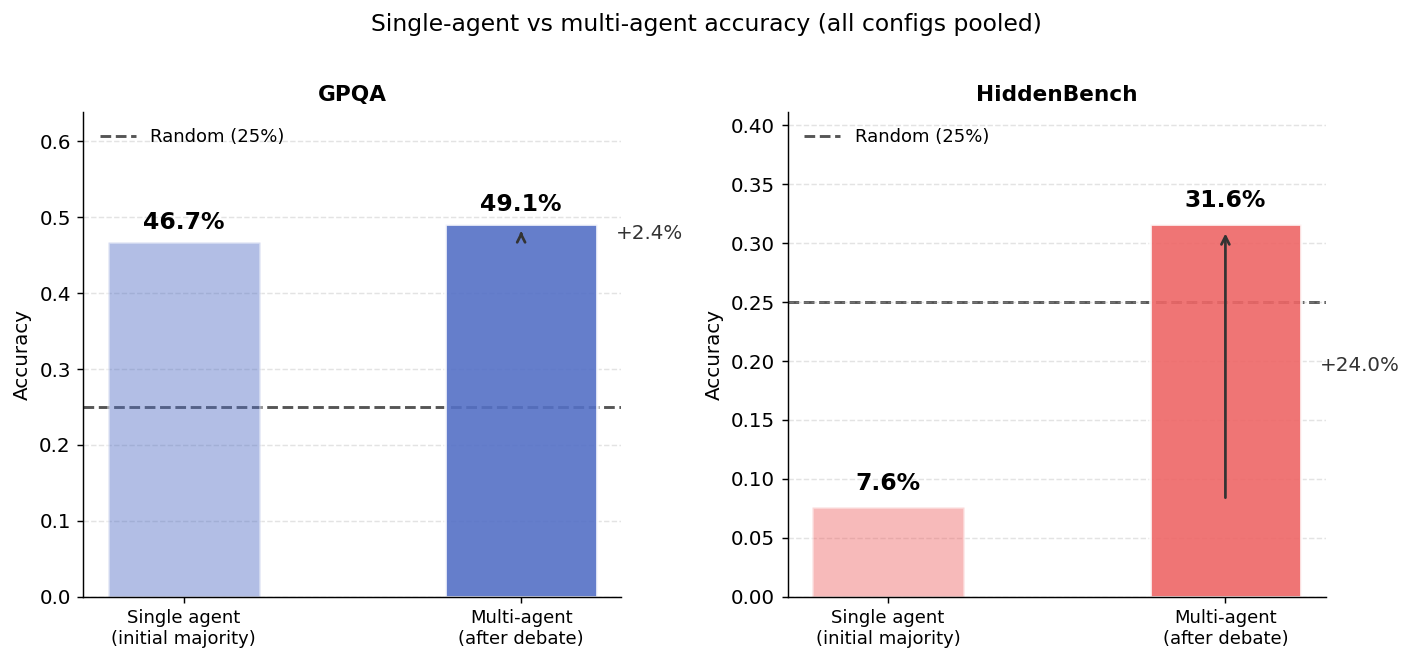

In [26]:
print('=== Single-agent (initial majority) vs multi-agent (after debate) ===')
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    init  = sub['init_correct'].mean()
    final = sub['correct'].mean()
    print(f'  {DS_LABELS[ds]:12s}  random={0.25:.3f}  single={init:.3f}  multi={final:.3f}  '
          f'debate_gain={final-init:+.3f}  lift_over_random={final-0.25:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

bar_labels = ['Single agent\n(initial majority)', 'Multi-agent\n(after debate)']

for col, ds in enumerate(DATASETS):
    ax  = axes[col]
    sub = reps_df[reps_df['dataset'] == ds]

    init_acc  = sub['init_correct'].mean()
    final_acc = sub['correct'].mean()
    vals      = [init_acc, final_acc]

    colors = [DS_COLORS[ds], DS_COLORS[ds]]
    alphas = [0.45, 0.9]
    for i, (val, lbl, col_c, alph) in enumerate(zip(vals, bar_labels, colors, alphas)):
        b = ax.bar(i, val, color=col_c, alpha=alph, width=0.45, edgecolor='white', linewidth=1.5)
        ax.text(i, val + 0.01, f'{val:.1%}', ha='center', va='bottom',
                fontweight='bold', fontsize=13)

    ax.axhline(0.25, color='#555', linestyle='--', linewidth=1.6, label='Random (25%)', zorder=0)

    # delta arrow annotation
    delta = final_acc - init_acc
    y_mid = (init_acc + final_acc) / 2
    ax.annotate('', xy=(1, final_acc - 0.005), xytext=(1, init_acc + 0.005),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
    ax.text(1.28, y_mid, f'{delta:+.1%}', ha='left', va='center', fontsize=11, color='#333')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(bar_labels, fontsize=10)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_title(DS_LABELS[ds])
    ax.legend(loc='upper left')
    ax.set_axisbelow(True)

fig.suptitle('Single-agent vs multi-agent accuracy (all configs pooled)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig1_single_vs_multi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2 — Effect of Topology

fc = fully connected, star = hub + 3 spokes. Accuracy and rounds pooled over W.

=== Topology: MWU tests (pooled over W) ===
  GPQA         accuracy  fc=0.502  star=0.480  Δ=+0.022  p=0.0866 ns
  GPQA         rounds    fc=4.047  star=4.474  Δ=-0.427  p=0.0000 ***
  HiddenBench  accuracy  fc=0.314  star=0.319  Δ=-0.005  p=0.6452 ns
  HiddenBench  rounds    fc=6.320  star=7.383  Δ=-1.063  p=0.0000 ***


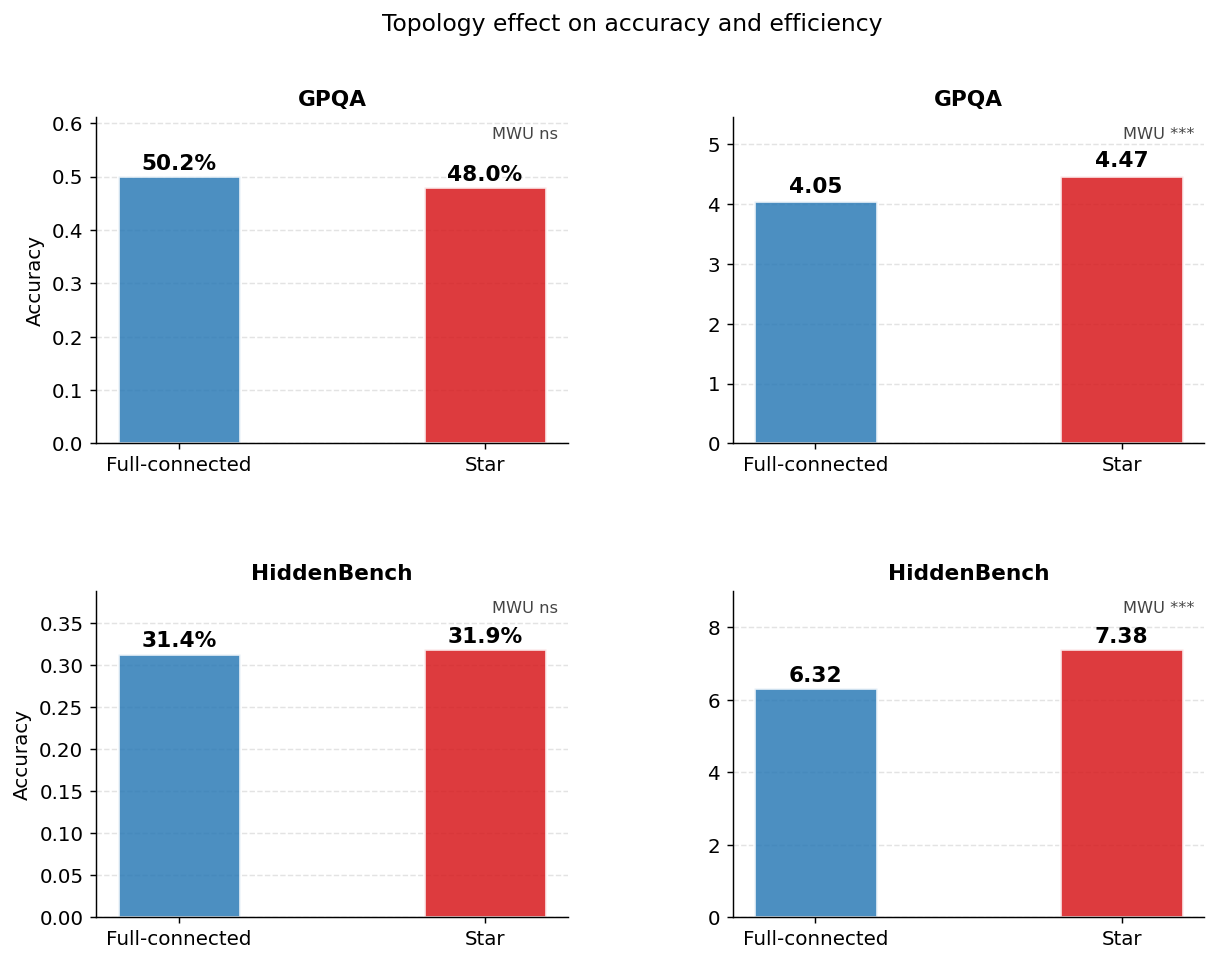

In [27]:
print('=== Topology: MWU tests (pooled over W) ===')
for ds in DATASETS:
    for metric, name in [('correct', 'accuracy'), ('n_rounds', 'rounds')]:
        fc_v   = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='fc')  ][metric]
        star_v = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='star')][metric]
        stat, p = sp_stats.mannwhitneyu(fc_v, star_v, alternative='two-sided')
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        print(f'  {DS_LABELS[ds]:12s} {name:8s}  fc={fc_v.mean():.3f}  star={star_v.mean():.3f}  '
              f'Δ={fc_v.mean()-star_v.mean():+.3f}  p={p:.4f} {sig}')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

metrics = [
    ('correct',  'Accuracy',               True,  0.60),
    ('n_rounds', 'Mean rounds to consensus', False, 10.0),
]

for col, (metric, ylabel, as_pct, y_top) in enumerate(metrics):
    for row, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = reps_df[reps_df['dataset'] == ds]

        means  = [sub[sub['topology']==t][metric].mean() for t in TOPOS]
        colors = [T_COLORS[t] for t in TOPOS]

        bars = ax.bar([T_LABELS[t] for t in TOPOS], means,
                      color=colors, alpha=0.85, width=0.4, edgecolor='white', linewidth=1.5)

        for bar, val in zip(bars, means):
            label = f'{val:.1%}' if as_pct else f'{val:.2f}'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.004 if as_pct else 0.08),
                    label, ha='center', va='bottom', fontsize=12, fontweight='bold')

        fc_v    = sub[sub['topology']=='fc'  ][metric]
        star_v  = sub[sub['topology']=='star'][metric]
        stat, p = sp_stats.mannwhitneyu(fc_v, star_v, alternative='two-sided')
        sig     = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        ax.text(0.98, 0.97, f'MWU {sig}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='#444')

        ax.set_title(DS_LABELS[ds])
        ax.set_ylabel(ylabel if col == 0 else '')
        ax.set_ylim(0, max(means) * 1.22)
        ax.set_axisbelow(True)

fig.suptitle('Topology effect on accuracy and efficiency', fontsize=13)
plt.savefig(PLOT_DIR / 'fig2_topology.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3 — Effect of Memory Window W

W ∈ {1, 2, 5}: how many prior rounds each agent includes in its context.

=== Memory window W: Kruskal-Wallis ===
  GPQA         fc    accuracy  W1=0.502  W2=0.497  W5=0.507  KW ns (p=0.9092)
  GPQA         fc    rounds    W1=4.000  W2=3.950  W5=4.190  KW ns (p=0.3947)
  GPQA         star  accuracy  W1=0.475  W2=0.488  W5=0.478  KW ns (p=0.8380)
  GPQA         star  rounds    W1=4.498  W2=4.329  W5=4.595  KW ns (p=0.2330)
  HiddenBench  fc    accuracy  W1=0.299  W2=0.321  W5=0.321  KW ns (p=0.4585)
  HiddenBench  fc    rounds    W1=6.486  W2=6.004  W5=6.470  KW * (p=0.0174)
  HiddenBench  star  accuracy  W1=0.304  W2=0.325  W5=0.329  KW ns (p=0.4236)
  HiddenBench  star  rounds    W1=7.784  W2=7.147  W5=7.220  KW *** (p=0.0000)


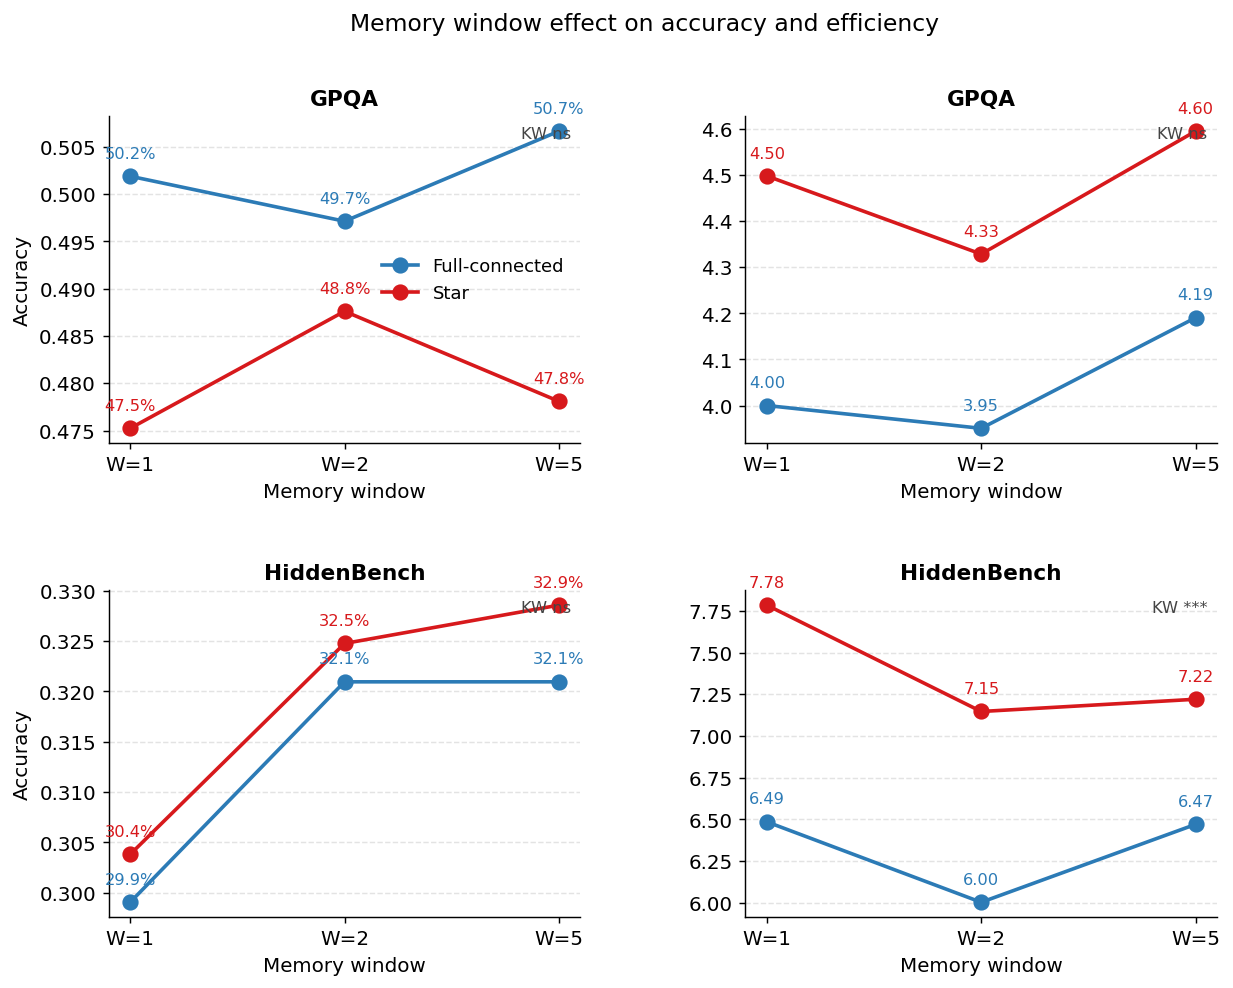

In [28]:
print('=== Memory window W: Kruskal-Wallis ===')
for ds in DATASETS:
    for topo in TOPOS:
        for metric, name in [('correct', 'accuracy'), ('n_rounds', 'rounds')]:
            sub = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']==topo)]
            groups = [sub[sub['W']==w][metric].values for w in W_VALUES]
            means  = [g.mean() for g in groups]
            stat, p = sp_stats.kruskal(*groups)
            sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} {name:8s}  '
                  f'W1={means[0]:.3f}  W2={means[1]:.3f}  W5={means[2]:.3f}  KW {sig} (p={p:.4f})')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

metrics = [
    ('correct',  'Accuracy',                True),
    ('n_rounds', 'Mean rounds to consensus', False),
]

for col, (metric, ylabel, as_pct) in enumerate(metrics):
    for row, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = reps_df[reps_df['dataset'] == ds]

        for topo in TOPOS:
            means = [sub[(sub['topology']==topo)&(sub['W']==w)][metric].mean()
                     for w in W_VALUES]
            ax.plot(range(len(W_VALUES)), means,
                    marker='o', linewidth=2, markersize=8,
                    color=T_COLORS[topo], label=T_LABELS[topo])
            for i, (w, m) in enumerate(zip(W_VALUES, means)):
                lbl = f'{m:.1%}' if as_pct else f'{m:.2f}'
                ax.annotate(lbl, (i, m),
                            textcoords='offset points', xytext=(0, 10),
                            ha='center', fontsize=9, color=T_COLORS[topo])

        # KW significance annotation (most conservative = pick worst p)
        p_vals = []
        for topo in TOPOS:
            g = [sub[(sub['topology']==topo)&(sub['W']==w)][metric].values for w in W_VALUES]
            _, p = sp_stats.kruskal(*g)
            p_vals.append(p)
        p_min = min(p_vals)
        sig   = '***' if p_min<0.001 else ('**' if p_min<0.01 else ('*' if p_min<0.05 else 'ns'))
        ax.text(0.98, 0.97, f'KW {sig}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='#444')

        ax.set_xticks(range(len(W_VALUES)))
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_xlabel('Memory window')
        ax.set_ylabel(ylabel if col == 0 else '')
        ax.set_title(DS_LABELS[ds])
        if row == 0 and col == 0:
            ax.legend()
        ax.set_axisbelow(True)

fig.suptitle('Memory window effect on accuracy and efficiency', fontsize=13)
plt.savefig(PLOT_DIR / 'fig3_memory_window.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4 — Round Distributions

Fraction of repetitions reaching each round count. Hard cap at T=15 shown by dashed line.

=== Fraction hitting hard cap T=15 ===
  GPQA         fc    W=1  p_cap=0.004
  GPQA         fc    W=2  p_cap=0.003
  GPQA         fc    W=5  p_cap=0.010
  GPQA         star  W=1  p_cap=0.017
  GPQA         star  W=2  p_cap=0.012
  GPQA         star  W=5  p_cap=0.024
  HiddenBench  fc    W=1  p_cap=0.112
  HiddenBench  fc    W=2  p_cap=0.106
  HiddenBench  fc    W=5  p_cap=0.146
  HiddenBench  star  W=1  p_cap=0.164
  HiddenBench  star  W=2  p_cap=0.170
  HiddenBench  star  W=5  p_cap=0.180


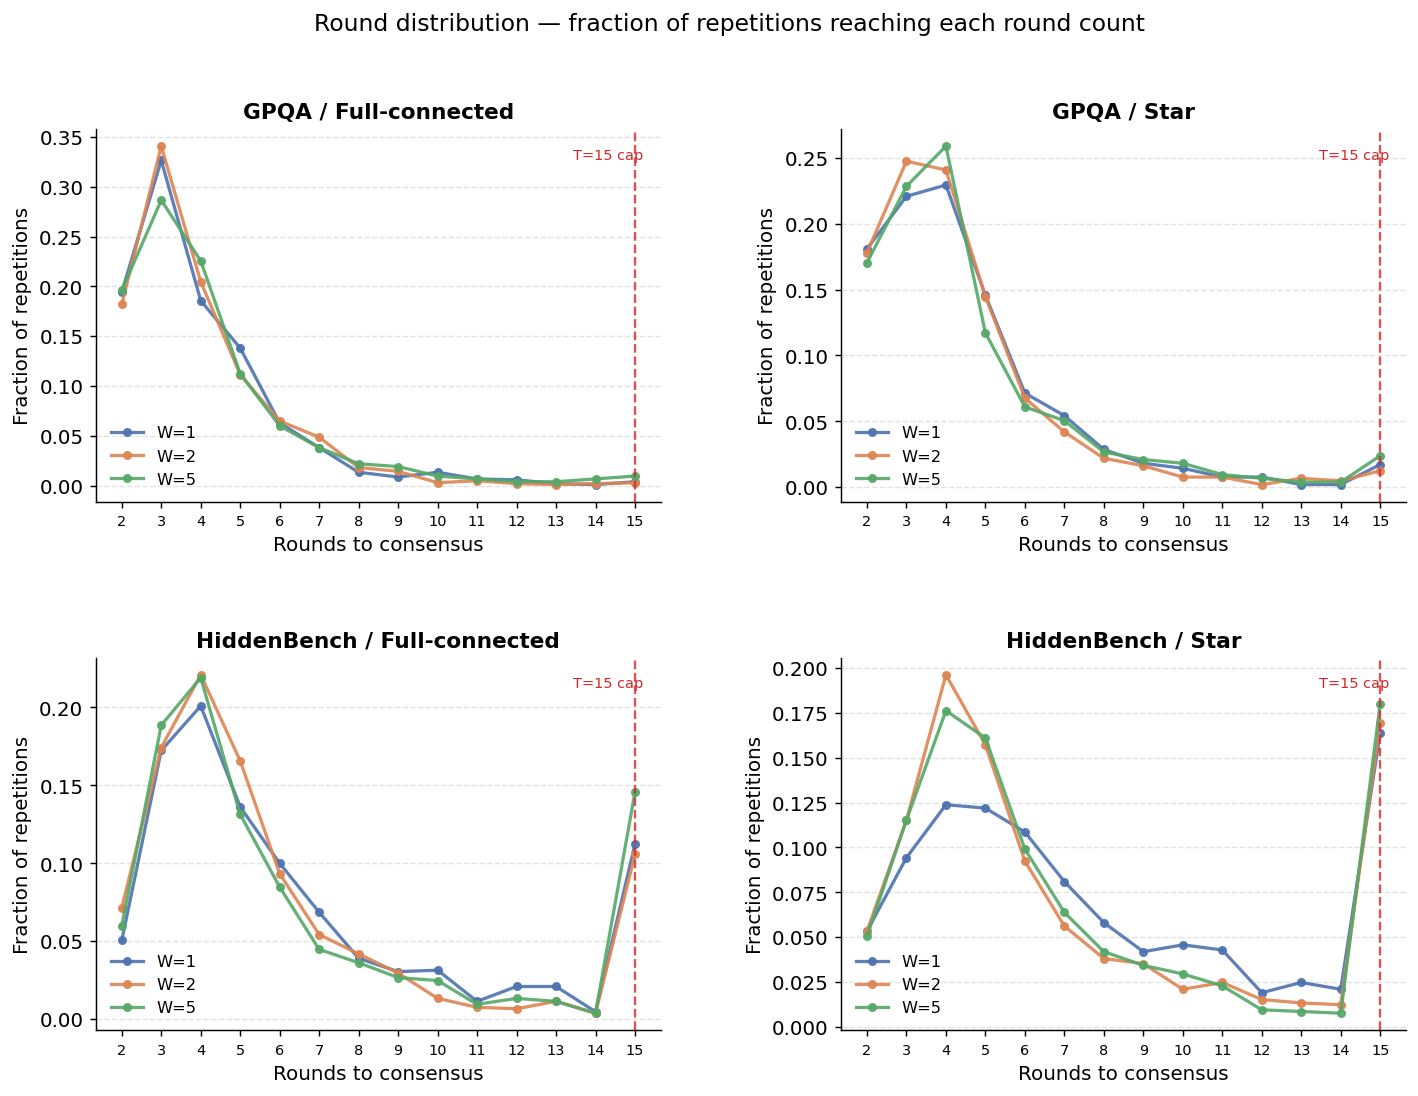

In [29]:
R_RANGE = range(2, 16)  # rounds in [2, 15]

print('=== Fraction hitting hard cap T=15 ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']==topo)&(reps_df['W']==w)]
            p   = (sub['n_rounds']==15).mean()
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  p_cap={p:.3f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(hspace=0.42, wspace=0.32)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = reps_df[(reps_df['dataset']==ds) & (reps_df['topology']==topo)]

        for w in W_VALUES:
            vals  = sub[sub['W']==w]['n_rounds'].values
            fracs = np.array([(vals == r).mean() for r in R_RANGE])
            ax.plot(list(R_RANGE), fracs,
                    marker='o', linewidth=1.8, markersize=4,
                    color=W_COLORS[w], label=f'W={w}', alpha=0.9)

        ax.axvline(15, color='#d62728', linestyle='--', linewidth=1.3, alpha=0.8)
        ax.text(0.97, 0.95, 'T=15 cap', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#d62728')

        ax.set_xticks(list(R_RANGE))
        ax.set_xticklabels([str(r) for r in R_RANGE], fontsize=8)
        ax.set_xlabel('Rounds to consensus')
        ax.set_ylabel('Fraction of repetitions')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=9)
        ax.set_axisbelow(True)

fig.suptitle('Round distribution — fraction of repetitions reaching each round count',
             fontsize=13)
plt.savefig(PLOT_DIR / 'fig4_round_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5 — Rounds vs Accuracy (the key asymmetry)

On GPQA fast consensus = right; on HiddenBench fast consensus = catastrophically wrong.

=== Accuracy binned by rounds (pooled over all configs, min 20 obs) ===
  GPQA
    rounds= 2  n=1157  acc=0.606
    rounds= 3  n=1734  acc=0.521
    rounds= 4  n=1413  acc=0.485
    rounds= 5  n= 808  acc=0.420
    rounds= 6  n= 407  acc=0.403
    rounds= 7  n= 285  acc=0.396
    rounds= 8  n= 137  acc=0.365
    rounds= 9  n= 102  acc=0.343
    rounds=10  n=  69  acc=0.464
    rounds=11  n=  45  acc=0.289
    rounds=12  n=  29  acc=0.241
    rounds=13  n=  20  acc=0.450
    rounds=14  n=  21  acc=0.429
    rounds=15  n=  73  acc=0.438
  HiddenBench
    rounds= 2  n= 356  acc=0.022
    rounds= 3  n= 903  acc=0.213
    rounds= 4  n=1194  acc=0.365
    rounds= 5  n= 917  acc=0.407
    rounds= 6  n= 607  acc=0.349
    rounds= 7  n= 387  acc=0.359
    rounds= 8  n= 268  acc=0.358
    rounds= 9  n= 208  acc=0.327
    rounds=10  n= 174  acc=0.368
    rounds=11  n= 125  acc=0.336
    rounds=12  n=  89  acc=0.404
    rounds=13  n=  95  acc=0.358
    rounds=14  n=  56  acc=0.357
    rounds=15  n

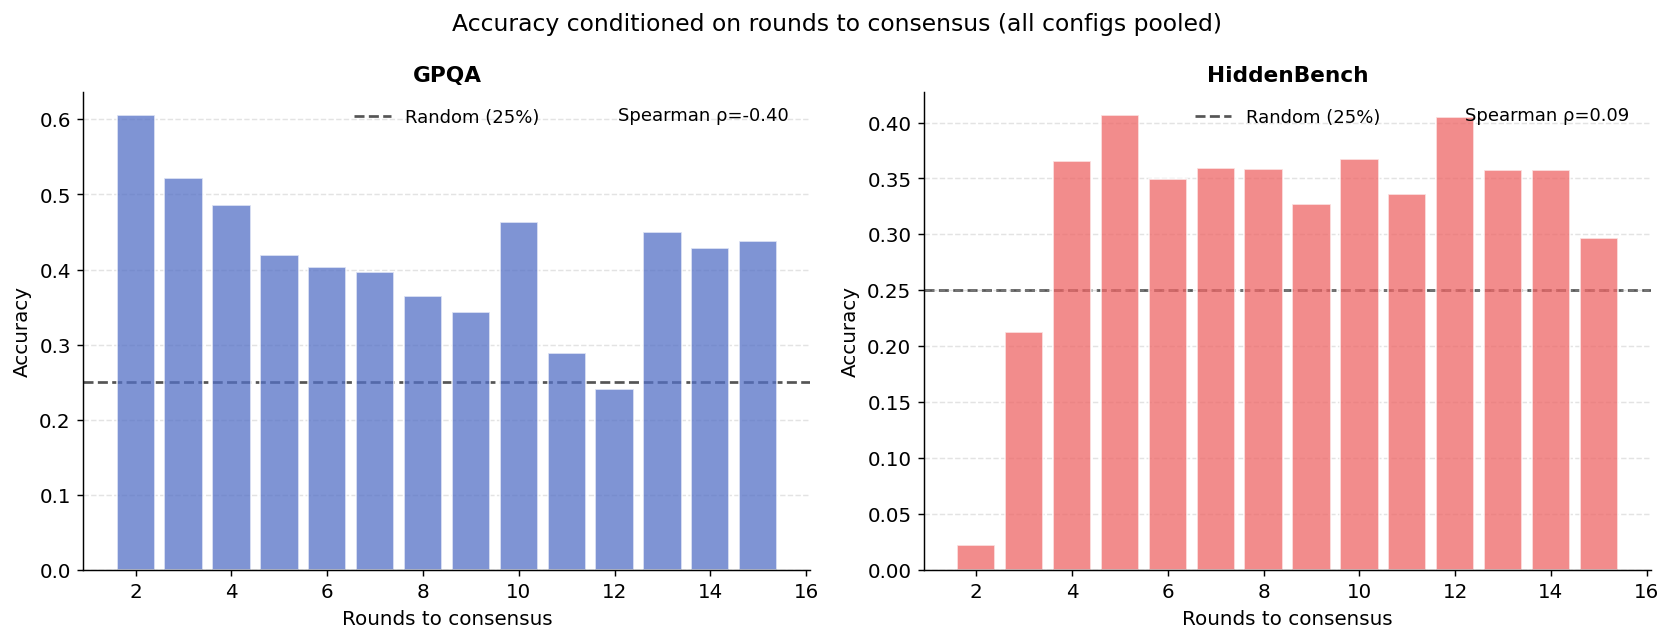

In [30]:
print('=== Accuracy binned by rounds (pooled over all configs, min 20 obs) ===')
for ds in DATASETS:
    sub = reps_df[reps_df['dataset']==ds]
    print(f'  {DS_LABELS[ds]}')
    for r_val in sorted(sub['n_rounds'].unique()):
        bucket = sub[sub['n_rounds']==r_val]
        if len(bucket) >= 20:
            print(f'    rounds={r_val:2d}  n={len(bucket):4d}  acc={bucket["correct"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for col, ds in enumerate(DATASETS):
    ax  = axes[col]
    sub = reps_df[reps_df['dataset']==ds]

    r_vals  = []
    acc_vals = []
    ns      = []
    for r_val in sorted(sub['n_rounds'].unique()):
        bucket = sub[sub['n_rounds']==r_val]
        if len(bucket) >= 20:
            r_vals.append(r_val)
            acc_vals.append(bucket['correct'].mean())
            ns.append(len(bucket))

    bars = ax.bar(r_vals, acc_vals, color=DS_COLORS[ds], alpha=0.75,
                  edgecolor='white', linewidth=1)
    ax.axhline(0.25, color='#555', linestyle='--', linewidth=1.5, label='Random (25%)', zorder=0)

    r, p = sp_stats.spearmanr(r_vals, acc_vals)
    ax.text(0.97, 0.97, f'Spearman ρ={r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10)

    ax.set_xlabel('Rounds to consensus')
    ax.set_ylabel('Accuracy')
    ax.set_title(DS_LABELS[ds])
    ax.legend()
    ax.set_axisbelow(True)

fig.suptitle('Accuracy conditioned on rounds to consensus (all configs pooled)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig5_rounds_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6 — Statistical Summary

In [31]:
print('=== Full summary: accuracy and rounds per config ===')
summary = (
    reps_df
    .groupby(['dataset', 'topology', 'W'])
    .agg(
        accuracy=('correct', 'mean'),
        mean_rounds=('n_rounds', 'mean'),
        p_hit_cap=('n_rounds', lambda x: (x == 15).mean()),
        mean_flips=('vote_flips', 'mean'),
    )
    .round(3)
)
print(summary.to_string())

print()
print('=== TOPOLOGY: rounds effect size summary ===')
for ds in DATASETS:
    fc_r   = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='fc')  ]['n_rounds']
    star_r = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='star')]['n_rounds']
    stat, p = sp_stats.mannwhitneyu(fc_r, star_r, alternative='two-sided')
    print(f'  {DS_LABELS[ds]:12s}  fc={fc_r.mean():.2f}  star={star_r.mean():.2f}  '
          f'Δ={star_r.mean()-fc_r.mean():+.2f} rounds  p={p:.4f}')

print()
print('=== TOPOLOGY: accuracy effect (not significant) ===')
for ds in DATASETS:
    fc_a   = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='fc')  ]['correct']
    star_a = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']=='star')]['correct']
    stat, p = sp_stats.mannwhitneyu(fc_a, star_a, alternative='two-sided')
    print(f'  {DS_LABELS[ds]:12s}  fc={fc_a.mean():.3f}  star={star_a.mean():.3f}  p={p:.4f} ns')

print()
print('=== W EFFECT: not significant on accuracy ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = reps_df[(reps_df['dataset']==ds)&(reps_df['topology']==topo)]
        groups = [sub[sub['W']==w]['correct'].values for w in W_VALUES]
        stat, p = sp_stats.kruskal(*groups)
        means = [g.mean() for g in groups]
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  '
              f'W1={means[0]:.3f}  W2={means[1]:.3f}  W5={means[2]:.3f}  KW p={p:.4f}')

=== Full summary: accuracy and rounds per config ===
                        accuracy  mean_rounds  p_hit_cap  mean_flips
dataset     topology W                                              
gpqa        fc       1     0.502        4.000      0.004       3.051
                     2     0.497        3.950      0.003       3.126
                     5     0.507        4.190      0.010       3.284
            star     1     0.475        4.498      0.017       3.457
                     2     0.488        4.329      0.012       3.718
                     5     0.478        4.595      0.024       3.754
hiddenbench fc       1     0.299        6.486      0.112       4.825
                     2     0.321        6.004      0.106       4.353
                     5     0.321        6.470      0.146       4.520
            star     1     0.304        7.784      0.164       5.485
                     2     0.325        7.147      0.170       5.272
                     5     0.329        7.220     